In [2]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

housing = fetch_openml(name="house_prices", as_frame=True, parser="auto")
df = housing.frame

X = df[['GrLivArea', 'LotArea', 'OverallQual']].copy()
y = df['SalePrice'].copy()

X = X.astype(float)
X.head()

,GrLivArea,LotArea,OverallQual
0,1710.0,8450.0,7.0
1,1262.0,9600.0,6.0
2,1786.0,11250.0,7.0
3,1717.0,9550.0,7.0
4,2198.0,14260.0,8.0


In [ ]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


<Axes: xlabel='SaleCondition', ylabel='SalePrice'>

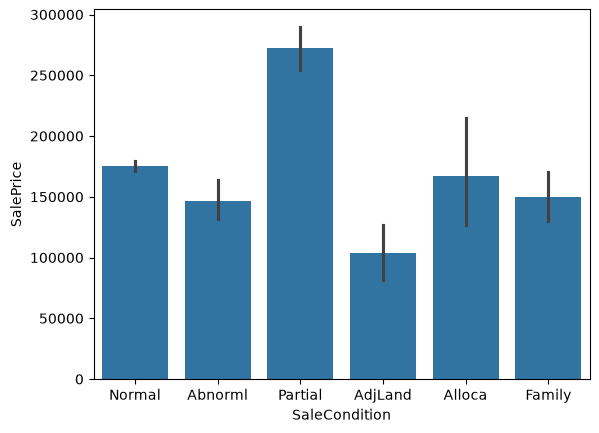

In [5]:
sns.barplot(data=df, x='SaleCondition', y='SalePrice')

In [ ]:
# 1.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(1168, 3) (292, 3)


count    1.168000e+03
mean     2.281280e-17
std      1.000428e+00
min     -8.730685e-01
25%     -2.884669e-01
50%     -1.013172e-01
75%      9.394519e-02
max      1.901998e+01
Name: std_LotArea, dtype: float64
count    1168.000000
mean        0.264942
std         2.616100
min        -2.018114
25%        -0.489393
50%         0.000000
75%         0.510607
max        50.001824
Name: rob_LotArea, dtype: float64


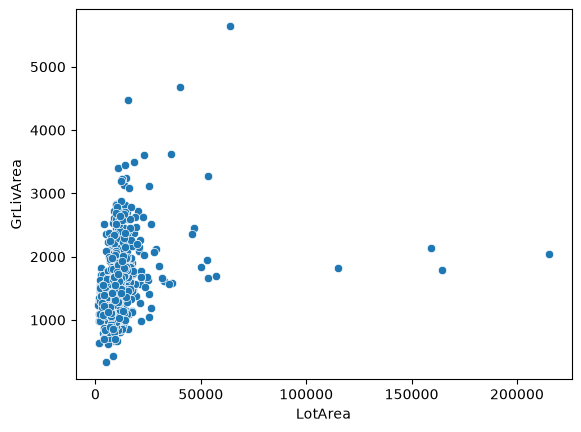

In [12]:
# 2.
sns.scatterplot(data=X_train, x='LotArea', y='GrLivArea')

scaler_std = StandardScaler()
X_train['std_LotArea'] = scaler_std.fit_transform(X_train[['LotArea']])

scaler_rob = RobustScaler()
X_train['rob_LotArea'] = scaler_rob.fit_transform(X_train[['LotArea']])

print(X_train['std_LotArea'].describe())
print(X_train['rob_LotArea'].describe())

In [ ]:
# 3.
scaler = MinMaxScaler()
X_train['sc_GrLivArea'] = scaler.fit_transform(X_train[['GrLivArea']])

X_test['sc_GrLivArea'] = scaler.transform(X_test[['GrLivArea']])
print(np.max(X_test['sc_GrLivArea']))


0.7501883948756594
